# Исследование метода KNN на наборе данных "Dry Bean Dataset"

Ссылка на набор данных: https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset

Загружаем необходимые библиотеки:

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

И сам датасет:

In [180]:
df = pd.read_csv("Dry_Bean.csv")

## Первичный анализ данных

Смотрим на первые пять строк набора данных:

In [86]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


И последние пять строк:

In [87]:
df.tail()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON
13610,42159,772.237,295.142741,182.204716,1.619841,0.786693,42600,231.686223,0.788962,0.989648,0.888380,0.784997,0.007001,0.001640,0.616221,0.998180,DERMASON


Выводим размер датасета (строки, столбцы):

In [88]:
df.shape

(13611, 17)

Далее общую обзорную информацию по столбцам:

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

Проверяем, есть ли пропущенные значения:

In [90]:
df.isna().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Формируем таблицу описательных статистик по вещественным признакам:

In [91]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


Далее исследуем распределение признаков:

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Perimeter'}>,
        <Axes: title={'center': 'MajorAxisLength'}>,
        <Axes: title={'center': 'MinorAxisLength'}>],
       [<Axes: title={'center': 'AspectRation'}>,
        <Axes: title={'center': 'Eccentricity'}>,
        <Axes: title={'center': 'ConvexArea'}>,
        <Axes: title={'center': 'EquivDiameter'}>],
       [<Axes: title={'center': 'Extent'}>,
        <Axes: title={'center': 'Solidity'}>,
        <Axes: title={'center': 'roundness'}>,
        <Axes: title={'center': 'Compactness'}>],
       [<Axes: title={'center': 'ShapeFactor1'}>,
        <Axes: title={'center': 'ShapeFactor2'}>,
        <Axes: title={'center': 'ShapeFactor3'}>,
        <Axes: title={'center': 'ShapeFactor4'}>]], dtype=object)

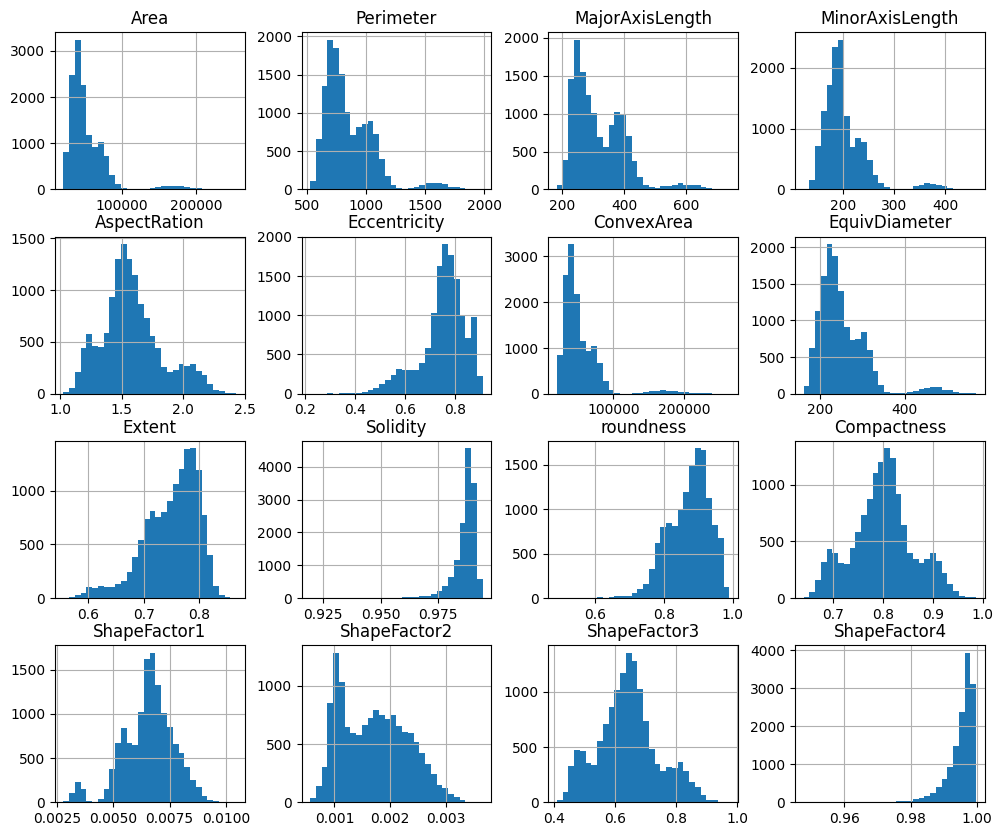

In [92]:
df.hist(bins=30, figsize=(12, 10))

Можно заметить, что признаки имеют разные масштабы, что нужно будет исправить для хорошей работы метода KNN.

Смотрим, сколько у нас классов в целевой колонке:

In [93]:
df["Class"].unique()

<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

А также как у нас сбалансированы эти классы:

<Axes: xlabel='Class', ylabel='count'>

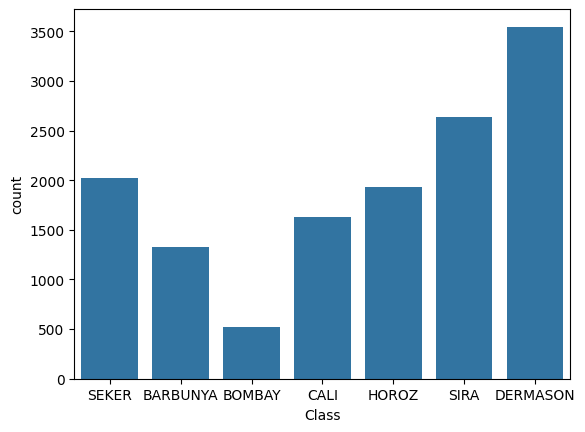

In [94]:
sns.countplot(df, x="Class")

Видно, что некоторые классы уступают другим по количеству записей в наборе данных.

Далее формируем матрицу корреляций и тепловую карту по ней:

<Axes: >

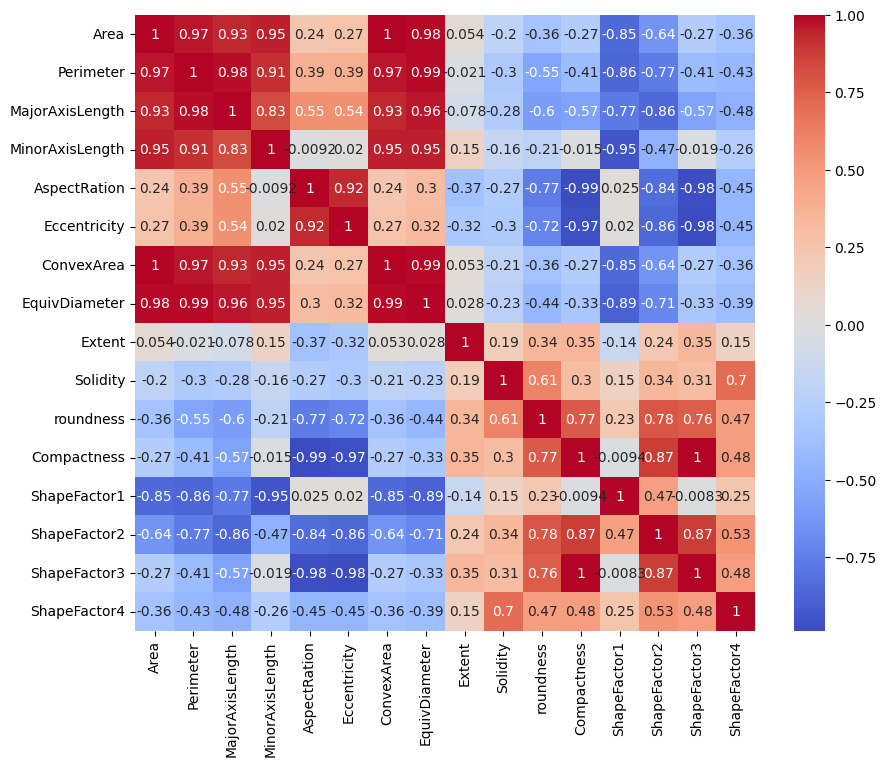

In [97]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

Теперь можно увидеть явные зависимости, во многом связанные с размерами изображений фасоли.

Можем составить точечные графики из коррелирующих признаков, разделённые по классам, чтобы увидеть потенциальное разделение:

<Axes: xlabel='MajorAxisLength', ylabel='Compactness'>

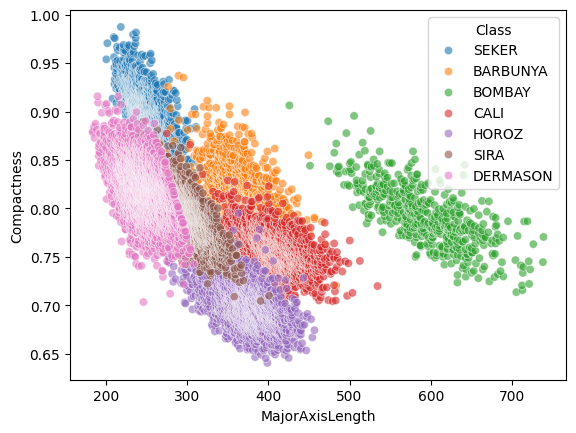

In [187]:
sns.scatterplot(df, x="MajorAxisLength", y="Compactness", hue="Class", alpha=0.6)

<Axes: xlabel='Area', ylabel='Eccentricity'>

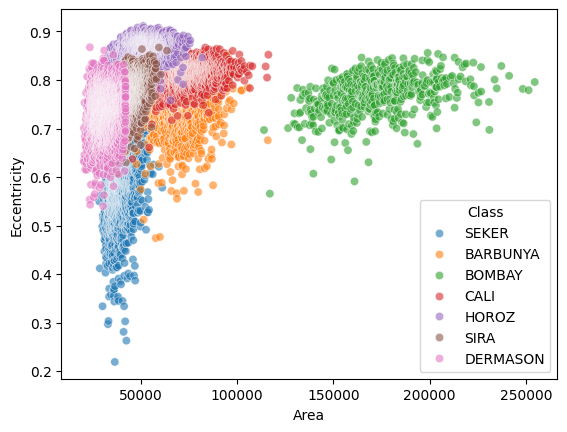

In [188]:
sns.scatterplot(df, x="Area", y="Eccentricity", hue="Class", alpha=0.6)

Видим, что очень много данных расположены довольно плотно друг к другу, что влияет на выбор значения k.

## Подготовка данных

В наборе данных категориальным признаком является только целевая переменная - класс объекта. Для её кодирования целесообразно использовать LabelEncoder, который сопоставляет каждому классу уникальное числовое значение. В отличие от признаков, где такое кодирование могло бы привести к появлению ложного порядка между значениями, для целевой переменной это не является проблемой, поскольку модель использует метки классов только для сравнения и не интерпретирует их как числовые величины.

In [189]:
from sklearn.preprocessing import LabelEncoder

lb_encoder = LabelEncoder()
df["Class"] = lb_encoder.fit_transform(df["Class"])
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5


Разделяем данные на матрицу признаков и вектор целевой переменной:

In [126]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Далее разделяем данные на обучающую и тестовую выборки:

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

И стандартизируем признаки:

In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Масштабирование признаков важно для метода KNN, так как предсказание класса или значения происходит за счёт вычисления расстояния до k-ближайших соседних признаков. А если признаки будут иметь разный масштаб, то один будут "более значимы", чем другие, что будет давать неправильные прогнозы модели.

Параметры модели не подбираются на тестовой выборки из-за смысла этой самой выборки. Тестовая выборка должна показать, настолько хорошо модель работает с неизвестными данными, а если мы уже на них "взглянули", то это может привести к ошибочно хорошему результату, произайдёт утечка данных.

## Обучение KNN

Обучим модель KNN сразу на нескольких разных параметрах **n_neighbors**, **weights** и **metric**, чтобы проследить их влияние на точность модели:

In [170]:
from sklearn.neighbors import KNeighborsClassifier

results = []

for k in [1, 3, 5, 9, 12]:
    for weights in ["uniform", "distance"]:
        for metric in ["euclidean", "manhattan", "minkowski"]:
            knn = KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric)
            knn.fit(X_train_scaled, y_train)
            accuracy = knn.score(X_test_scaled, y_test)
            
            results.append({
                "k": k,
                "weights": weights,
                "metric": metric,
                "accuracy": accuracy
            })

df_results = pd.DataFrame(results)

Получаем таблицу со значениями параметров и точностью модели.

## Подбор гиперпараметров

Посмотрим, какие комбинации гиперпараметров дают наибольшую точность:

In [171]:
df_results.sort_values(by="accuracy", ascending=False).head()

,k,weights,metric,accuracy
29,12,distance,minkowski,0.926919
27,12,distance,euclidean,0.926919
17,5,distance,minkowski,0.926552
15,5,distance,euclidean,0.926552
8,3,uniform,minkowski,0.925450


Отдельно на гиперпараметр **n_neighbors**:

In [154]:
df_results.groupby("k")["accuracy"].mean()

k
1     0.909291
3     0.922022
5     0.923797
9     0.923063
12    0.923552
Name: accuracy, dtype: float64

Сравнивая точность модели при разных значениях k, можем сделать вывод, что при слишком малом количестве соседей *(например, всего лишь **одном**)* модель сильно теряет в точности. В таком случае модель сильно переобучится. Если же наоборот - k будет довольно большим, то модель будет уже недообучена и давать такой же довольно посредственный результат.

На **weights**:

In [155]:
df_results.groupby("weights")["accuracy"].mean()

weights
distance    0.921116
uniform     0.919574
Name: accuracy, dtype: float64

На **metric**:

In [156]:
df_results.groupby("metric")["accuracy"].mean()

metric
euclidean    0.922145
manhattan    0.916746
minkowski    0.922145
Name: accuracy, dtype: float64

Для метрик расстояний результатом сравнения является тот факт, что лучшими по точности являются евклидовая метрика и метрика Минковского.

Также сформируем свободную таблицу:

In [157]:
pd.pivot_table(
    df_results,
    values="accuracy",
    index="k",
    columns="metric"
)

metric,euclidean,manhattan,minkowski
k,,,
1,0.910760,0.906353,0.910760
3,0.925450,0.915167,0.925450
5,0.924899,0.921594,0.924899
9,0.924715,0.919758,0.924715
12,0.924899,0.920859,0.924899


Проверим теперь зависимость точности модели от масштабирования признаков:

In [158]:
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(X_train, y_train)
print(f"Без масштабирования: {model.score(X_test, y_test):.3f}")

knn.fit(X_train_scaled, y_train)
print(f"С масштабированием: {model.score(X_test_scaled, y_test):.3f}")

Без масштабирования: 0.043
С масштабированием: 0.927


F:\Прога\DS-ML\ml-famcs-course-homeworks\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Как видно, масштабирование значительным образом *(в целых 20 раз!)* влияет на качество предсказаний модели KNN.

Далее найдём самые лучшие параметры модели с помощью поиска по сетке:

In [169]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 12],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

knn_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [172]:
knn_grid.best_params_

{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}

Результатом является количество соседей *k = 9*, метрика расстояний - *евклидова*, и тип весов - *distance*.

In [173]:
knn_grid.best_score_

np.float64(0.9241372255987865)

Получаем точность в **92%!**

Проверим этот результат методом кросс-валидации:

In [175]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=9, metric="euclidean", weights="distance")

cros_val_scores = cross_val_score(knn, X_train_scaled, y_train)

In [176]:
cros_val_scores.mean()

np.float64(0.9241372255987865)

Всё совпадает! Результаты очень хорошие для набора данных и алгоритма.

## Выводы

- Датасет содержит числовые признаки, описывающие геометрические характеристики объектов (форму фасоли), что делает его удобным для алгоритмов, основанных на расстояниях.

- Целевая переменная является категориальной (сорта фасоли) и была закодирована с помощью Label Encoding без потери смысла.

- Признаки имеют разный масштаб, поэтому масштабирование данных является необходимым этапом предобработки.

- В данных наблюдается корреляция между некоторыми признаками (например, размерными характеристиками), что может влиять на вычисление расстояний.

- Алгоритм KNN показал хорошее качество на данном датасете, что связано с геометрической природой признаков.

- Оптимальное значение числа соседей оказалось равным k = 9, что свидетельствует о необходимости баланса между переобучением (малые k) и недообучением (большие k).

- Масштабирование признаков существенно влияет на качество KNN и является обязательным для корректной работы алгоритма.

Полученный результат подтверждает, что KNN является эффективным методом для задач классификации с компактными и хорошо разделимыми классами в пространстве признаков.